# 01 — Baseline Controllers: Thermostat & PID

This notebook evaluates the two rule-based baselines on the `HvacEnv`:
- **Thermostat**: simple on/off hysteresis controller
- **PID**: proportional–integral–derivative controller

We run each policy across 20 episodes (cold, mild, hot days) and compare:
- Indoor temperature trajectories
- HVAC power usage
- Comfort deviation distributions
- Energy vs comfort trade-off (Pareto scatter)


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 10

from smart_hvac.core.parameters import Parameters
from smart_hvac.envs.hvac_env import HvacEnv
from smart_hvac.control.thermostat import Thermostat
from smart_hvac.control.pid_controller import PIDController
from smart_hvac.evaluation.rollouts import run_rollout, run_rollouts
from smart_hvac.evaluation.metrics import compute_metrics, aggregate_metrics, metrics_table
from smart_hvac.evaluation.plots import (
    plot_timeseries,
    plot_temperature_distribution,
    plot_pareto,
    plot_cumulative_costs,
)

import os
os.makedirs('../results/figures', exist_ok=True)

params = Parameters()
print(f'Parameters loaded | dt={params.dt}s | episode={params.episode_duration_h:.0f}h | P_max={params.P_max}W')
print(f'Comfort band: [{params.T_min}, {params.T_max}] °C | tau={params.tau/3600:.2f}h')

Parameters loaded | dt=900.0s | episode=24h | P_max=3000.0W
Comfort band: [21.0, 23.0] °C | tau=2.08h


## 1.1 Single episode — cold day visual inspection

In [2]:
CAUSAL_SEED = 42

policies = {
    'Thermostat': (Thermostat(params=params), True),
    'PID':        (PIDController(params=params), True),
}

cold_trajs = {}
for name, (policy, is_bl) in policies.items():
    env = HvacEnv(params=params, day_type='cold', seed=CAUSAL_SEED)
    traj = run_rollout(policy, env, seed=CAUSAL_SEED, is_baseline=is_bl)
    cold_trajs[name] = traj
    m = compute_metrics(traj)
    print(f'{name:12s} | comfort_dev={m["mean_comfort_dev"]:.3f}K | in_band={m["pct_in_band"]:.1f}% | energy={m["total_energy_kwh"]:.3f}kWh')

Thermostat   | comfort_dev=3.400K | in_band=26.0% | energy=71.250kWh
PID          | comfort_dev=3.468K | in_band=19.8% | energy=69.617kWh


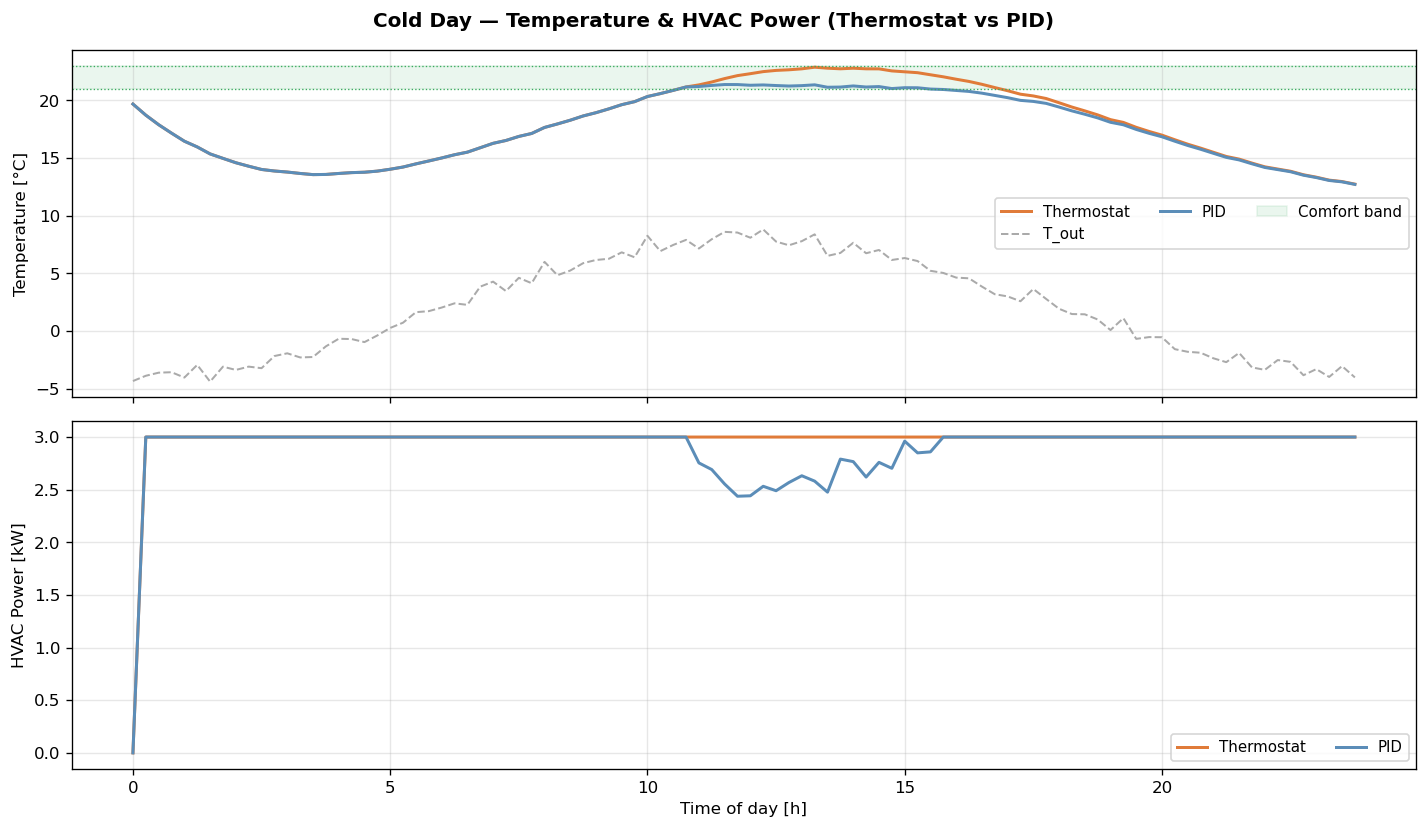

In [3]:
fig = plot_timeseries(
    cold_trajs,
    T_min=params.T_min, T_max=params.T_max,
    title='Cold Day — Temperature & HVAC Power (Thermostat vs PID)'
)
fig.savefig('../results/figures/01_cold_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.2 Single episode — hot day

Thermostat   | comfort_dev=5.231K | in_band=14.6% | energy=0.000kWh
PID          | comfort_dev=5.231K | in_band=14.6% | energy=0.000kWh


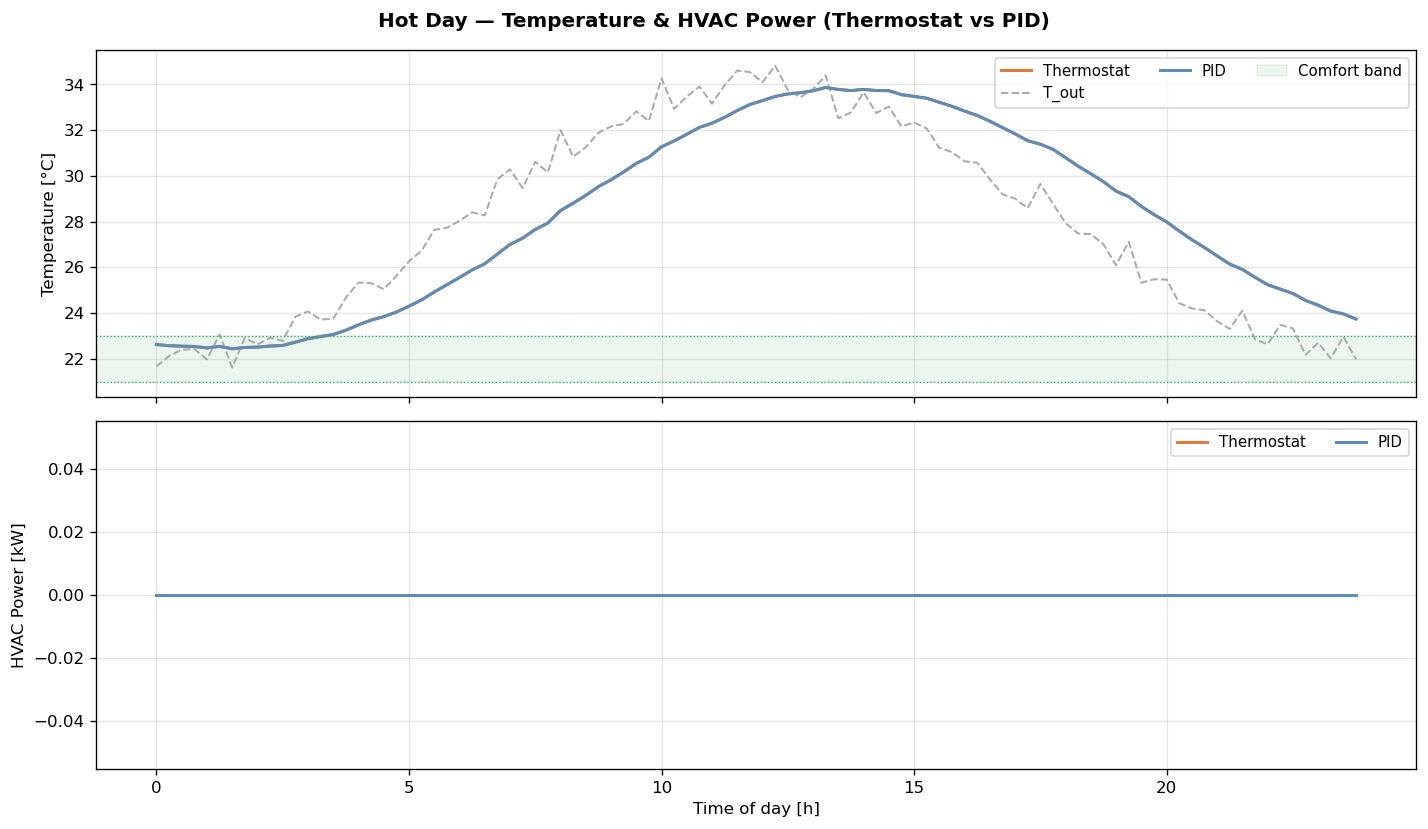

In [4]:
hot_trajs = {}
for name, (policy, is_bl) in policies.items():
    env = HvacEnv(params=params, day_type='hot', seed=CAUSAL_SEED)
    traj = run_rollout(policy, env, seed=CAUSAL_SEED, is_baseline=is_bl)
    hot_trajs[name] = traj
    m = compute_metrics(traj)
    print(f'{name:12s} | comfort_dev={m["mean_comfort_dev"]:.3f}K | in_band={m["pct_in_band"]:.1f}% | energy={m["total_energy_kwh"]:.3f}kWh')

fig = plot_timeseries(
    hot_trajs,
    T_min=params.T_min, T_max=params.T_max,
    title='Hot Day — Temperature & HVAC Power (Thermostat vs PID)'
)
fig.savefig('../results/figures/01_hot_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 Multi-episode statistics (20 episodes per day type)

In [5]:
N_EPISODES = 20
all_metrics   = {}   # policy → mean metrics dict
all_ep_metrics = {}  # policy → list of per-episode metrics

for name, (policy, is_bl) in policies.items():
    env = HvacEnv(params=params, day_type='random', seed=0)
    trajs = run_rollouts(policy, env, n_episodes=N_EPISODES, base_seed=0, is_baseline=is_bl)
    ep_m = [compute_metrics(t) for t in trajs]
    agg  = aggregate_metrics(trajs)
    all_metrics[name]    = {k: v['mean'] for k, v in agg.items()}
    all_ep_metrics[name] = ep_m

print('\n=== 20-episode aggregate (random day mix) ===')
print(metrics_table(all_metrics))


=== 20-episode aggregate (random day mix) ===
Metric                           Thermostat               PID
-------------------------------------------------------------
mean_comfort_dev                     3.5163            3.4912
pct_in_band                         31.1979           37.2396
total_energy_kwh                    20.8875           20.4006
mean_power_w                       870.3125          850.0253
total_reward                     -2661.1673        -2662.2079


## 1.4 Temperature distribution

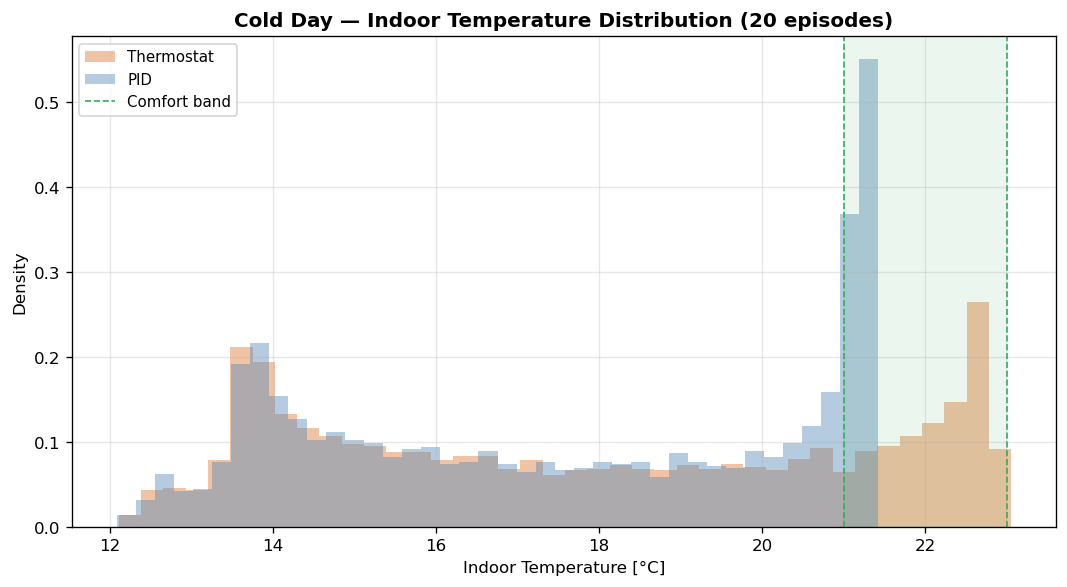

In [6]:
# Collect all T_in across 20 episodes per policy for histogram
dist_trajs = {}
for name, (policy, is_bl) in policies.items():
    env = HvacEnv(params=params, day_type='cold', seed=0)
    trajs = run_rollouts(policy, env, n_episodes=N_EPISODES, base_seed=0, is_baseline=is_bl)
    # Concatenate all T_in arrays
    combined = np.concatenate([t['T_in'] for t in trajs])
    dist_trajs[name] = {'T_in': combined}

fig = plot_temperature_distribution(
    dist_trajs,
    T_min=params.T_min, T_max=params.T_max,
    title='Cold Day — Indoor Temperature Distribution (20 episodes)'
)
fig.savefig('../results/figures/01_temp_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.5 Comfort vs Energy Pareto scatter

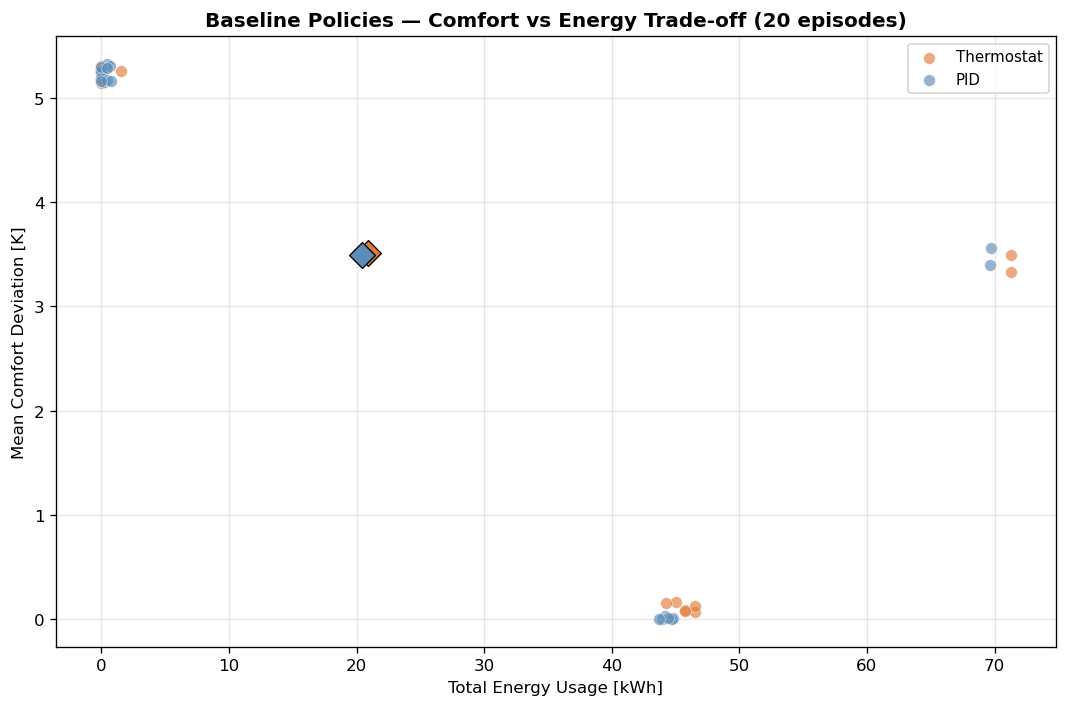

In [7]:
fig = plot_pareto(
    all_ep_metrics,
    title='Baseline Policies — Comfort vs Energy Trade-off (20 episodes)'
)
fig.savefig('../results/figures/01_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.6 Cumulative cost — causal fixed day

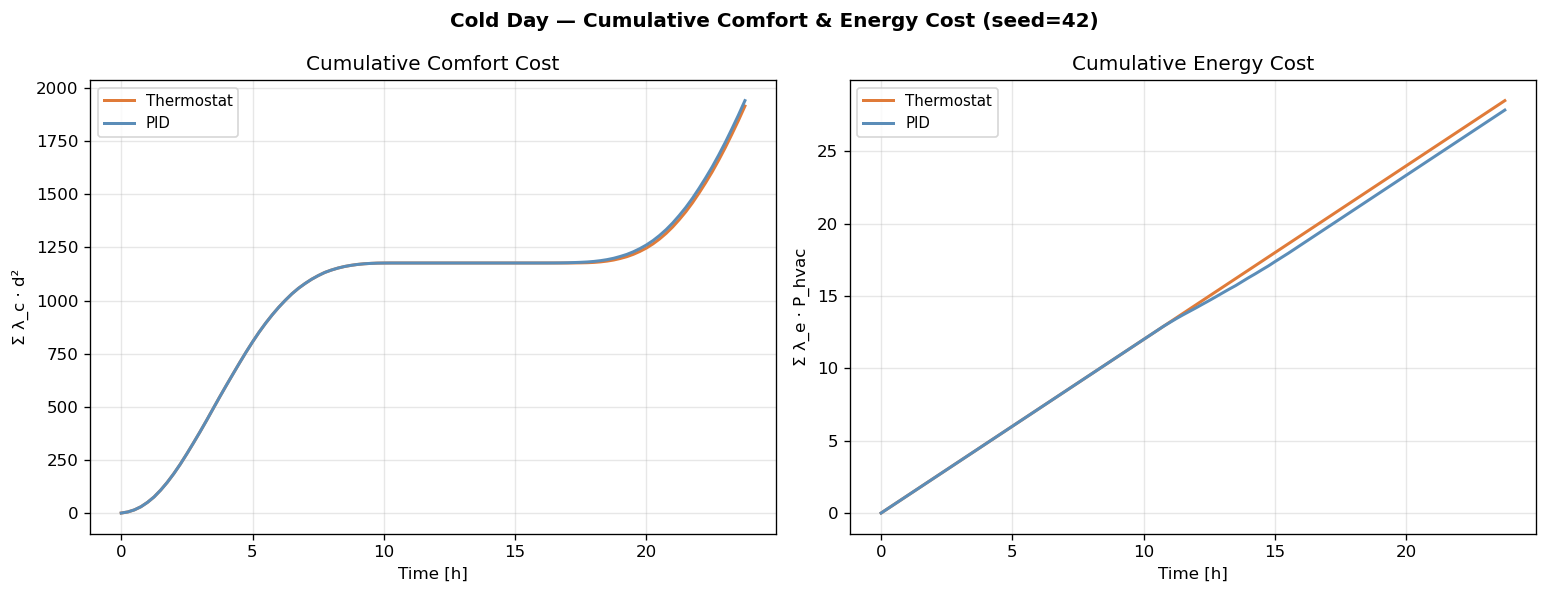

In [8]:
fig = plot_cumulative_costs(
    cold_trajs,
    lambda_c=params.lambda_c,
    lambda_e=params.lambda_e,
    title='Cold Day — Cumulative Comfort & Energy Cost (seed=42)'
)
fig.savefig('../results/figures/01_cumulative_costs.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.7 Summary

| Observation | Interpretation |
|---|---|
| Thermostat oscillates around comfort band | Bang-bang causes temperature cycling (chattering) |
| PID tracks setpoint more smoothly | Integral term eliminates steady-state error |
| Both waste energy at night (no occupancy awareness) | Neither policy anticipates unoccupied periods |
| Pareto: both cluster in similar region | Room for RL to find a better comfort/energy frontier |

**These baselines set the performance floor that SAC must beat in notebook 02.**